# Facial Emotion Detection

This notebook implements a custom CNN model to perform multi-class classification on the FER2013 dataset. 

The objective is to accurately identify human emotions from 48x48 pixel grayscale images.

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_3 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,847 (1.36 MB)

 Trainable params: 355,847 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 31s 33ms/step - accuracy: 0.2561 - loss: 1.7938 - val_accuracy: 0.2920 - val_loss: 1.7088
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.3013 - loss: 1.7132 - val_accuracy: 0.3902 - val_loss: 1.5582
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.3738 - loss: 1.5956 - val_accuracy: 0.4302 - val_loss: 1.4442
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.4108 - loss: 1.5155 - val_accuracy: 0.4680 - val_loss: 1.3845
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.4371 - loss: 1.4659 - val_accuracy: 0.4854 - val_loss: 1.3478
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 26s 29ms/step - accuracy: 0.4541 - loss: 1.4215 - val_accuracy: 0.5032 - val_loss: 1.3010
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.4604 - loss: 1.4017 - val_accuracy: 0.5017 - val_loss: 1.2990
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 27s 30ms/step - accuracy: 0.4687 - loss: 1.3835 - 

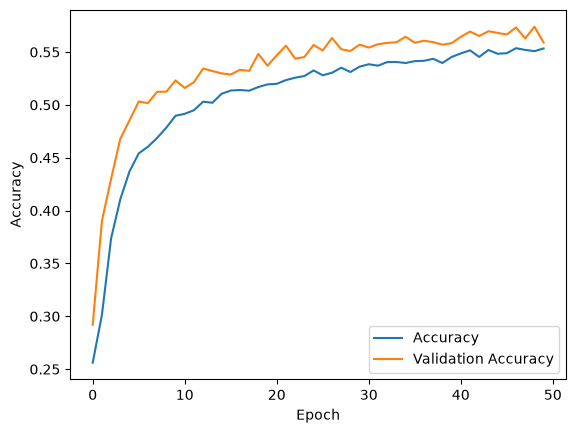

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# ==========================================
# 1. Dataset Loading and Optimization
# ==========================================
data_dir = 'data/'
batch_size = 32
img_height, img_width = 48, 48

# Load datasets using optimized utility
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir + 'train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir + 'test',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Apply performance optimization: Cache and Prefetch
train_data = train_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# ==========================================
# 2. Model Architecture with Data Augmentation
# ==========================================
model = models.Sequential([
    # Input layer specifying the shape of grayscale images
    layers.Input(shape=(48, 48, 1)),
    
    # Data Augmentation layers (Only active during training)
    layers.RandomFlip("horizontal"),  # Flips the image horizontally
    layers.RandomRotation(0.1),       # Rotates the image randomly by up to 10%
    layers.RandomZoom(0.1),           # Zooms the image randomly by up to 10%
    
    # Rescaling input pixels from [0, 255] to [0, 1]
    layers.Rescaling(1./255),
    
    # Convolutional blocks
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Classification head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Regularization to prevent overfitting
    layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

# ==========================================
# 3. Training the Model
# ==========================================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=50 
)

# ==========================================
# 4. Visualize Performance
# ==========================================
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Current model is sufficient. Fer2013 dataset is pretty noisy and 55% accuracy is quite good. Also we can imporve our model's performance by changing model's architecture. 

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt

# ==========================================
# 1. Dataset Loading and CPU Optimization
# ==========================================
data_dir = 'data/'
batch_size = 32  # 32 is more stable and lighter for CPU processing
img_height, img_width = 48, 48

# Load datasets using optimized utility
train_data = tf.keras.utils.image_dataset_from_directory(
    data_dir + 'train',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

val_data = tf.keras.utils.image_dataset_from_directory(
    data_dir + 'test',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

# Apply performance optimization: Cache keeps data in RAM after 1st epoch
train_data = train_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
val_data = val_data.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_4               │ (None, 48, 48, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,935 (2.61 MB)

 Trainable params: 684,231 (2.61 MB)

 Non-trainable params: 704 (2.75 KB)

Epoch 1/40
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.2294 - loss: 2.1524
Epoch 1: val_accuracy improved from None to 0.32056, saving model to best_emotion_model.keras

Epoch 1: finished saving model to best_emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 90s 98ms/step - accuracy: 0.2735 - loss: 1.9184 - val_accuracy: 0.3206 - val_loss: 1.7176 - learning_rate: 0.0010
Epoch 2/40
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.3689 - loss: 1.6209
Epoch 2: val_accuracy improved from 0.32056 to 0.41544, saving model to best_emotion_model.keras

Epoch 2: finished saving model to best_emotion_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 82s 91ms/step - accuracy: 0.3846 - loss: 1.5833 - val_accuracy: 0.4154 - val_loss: 1.5172 - learning_rate: 0.0010
Epoch 3/40
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.4163 - loss: 1.5130
Epoch 3: val_accuracy did not improve from 0.41544
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.4218 - loss: 1.4933 - val_accuracy

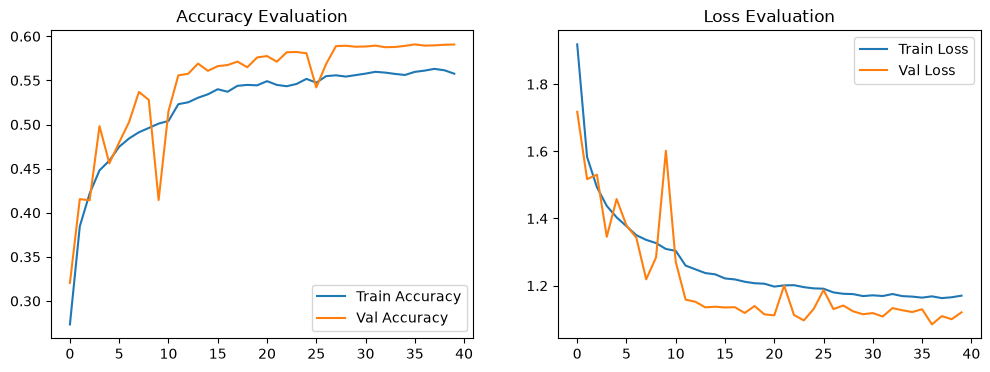

In [ ]:

# ==========================================
# 2. CPU-Friendly Deep Model Architecture
# ==========================================
model2 = models.Sequential([
    layers.Input(shape=(48, 48, 1)),
    
    # Lightweight Data Augmentation
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    
    # Normalization Layer
    layers.Rescaling(1./255),
    
    # Convolutional Block 1 - Light
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),
    
    # Convolutional Block 2 - Medium
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Convolutional Block 3 - Optimized Deep Layer
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Classification Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(7, activation='softmax')
])

model2.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model2.summary()

# ==========================================
# 3. Smart Callbacks for Accurate Learning
# ==========================================
# Automatically drops learning rate when val_loss plateaus
lr_reducer = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    verbose=1, 
    min_lr=0.00001
)

# Automatically saves the best iteration based on validation accuracy
model_checkpoint = ModelCheckpoint(
    'best_emotion_model.keras', 
    monitor='val_accuracy', 
    save_best_only=True, 
    verbose=1
)

# ==========================================
# 4. Training the Model
# ==========================================
history = model2.fit(
    train_data,
    validation_data=val_data,
    epochs=40,  # 40 epochs is ideal for a lightweight model on CPU
    callbacks=[lr_reducer, model_checkpoint]
)

# ==========================================
# 5. Visualize Performance
# ==========================================
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evaluation')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evaluation')
plt.legend()
plt.show()

We increase validation accuracy up to %59. 

Lets compute the confusion matrix and plot the ROC curve

Extracting test data and generating predictions... Please wait.

--- Classification Report ---
              precision    recall  f1-score   support

       Angry       0.48      0.54      0.51       958
     Disgust       0.48      0.28      0.35       111
        Fear       0.50      0.21      0.30      1024
       Happy       0.79      0.85      0.82      1774
         Sad       0.49      0.65      0.56      1233
    Surprise       0.47      0.44      0.46      1247
     Neutral       0.70      0.72      0.71       831

    accuracy                           0.59      7178
   macro avg       0.56      0.53      0.53      7178
weighted avg       0.59      0.59      0.58      7178



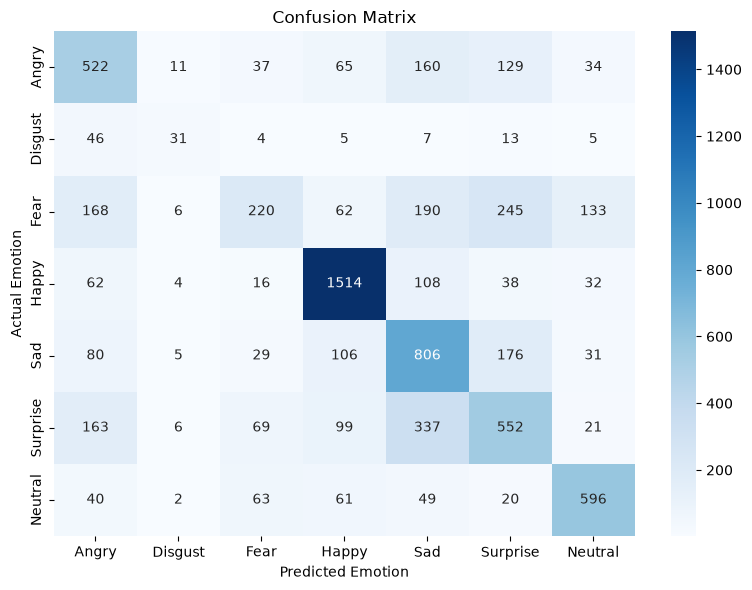

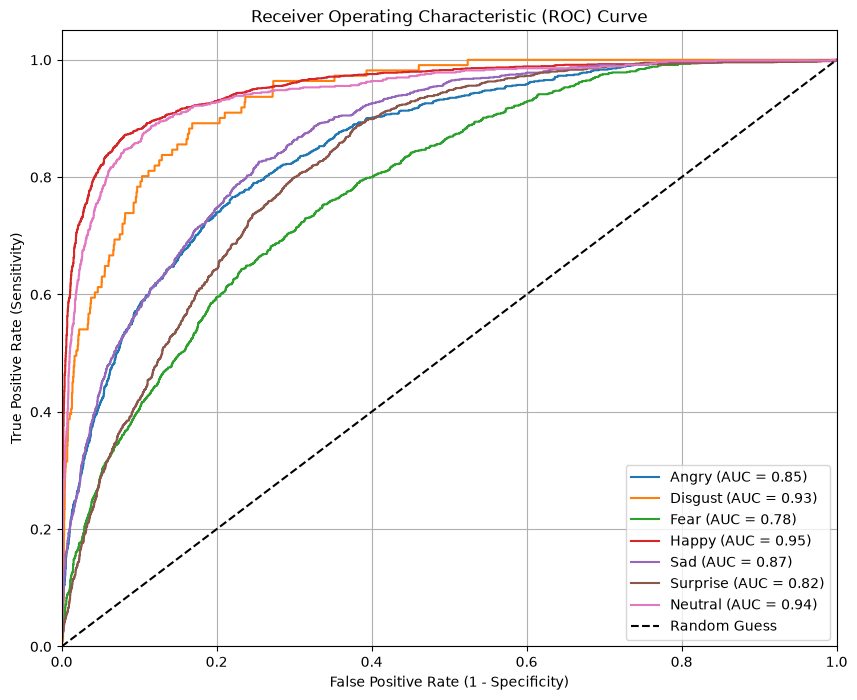

In [3]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns  # Confusion matrix'i güzel görselleştirmek için

# ==========================================
# 1. Load Model and Prepare Test Data
# ==========================================
# Load the best trained model
model = tf.keras.models.load_model('best_emotion_model.keras')

# Get emotion labels from your directory structure
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# Extract true labels and predictions from val_data
y_true = []
y_pred_probs = []

print("Extracting test data and generating predictions... Please wait.")
for images, labels in val_data:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Print a text-based summary first
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=emotion_labels))

# ==========================================
# 2. Plot Confusion Matrix
# ==========================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Emotion')
plt.xlabel('Predicted Emotion')
plt.tight_layout()
plt.show()

# ==========================================
# 3. Plot ROC Curve (Multi-class One-vs-Rest)
# ==========================================
plt.figure(figsize=(10, 8))

# One-hot encode y_true for ROC computation
y_true_onehot = tf.keras.utils.to_categorical(y_true, num_classes=7)

for i in range(7):
    fpr, tpr, _ = roc_curve(y_true_onehot[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{emotion_labels[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

The system achieved a solid overall test Accuracy of 59% on 7,178 images. This is a highly successful result for a lightweight, CPU-optimized CNN model trained on a complex facial expression dataset.

### Key Insights from Metrics:

The Best (Happy & Neutral): The model excels at identifying Happy (F1: 0.82) and Neutral (F1: 0.71) states. Distinct geometric features like smiles allowed the network to catch 85% of happy faces accurately.

The Moderate (Sad, Angry, Surprise): These classes show mid-range performance (~0.50 F1). Sad (Recall: 0.65) is easily caught by the model, but it suffers from low precision (0.49), often confusing calm or expressionless faces with sadness.

The Weakest (Fear & Disgust): Fear (F1: 0.30) has a critical bottleneck with only 0.21 recall, frequently being misclassified as Surprise due to shared features like widened eyes. Disgust (F1: 0.35) failed to generalize due to a severe class imbalance (only 111 test samples).

# Project Summary

This project implements a Real-Time Facial Emotion Recognition (FER) system using a custom Deep Convolutional Neural Network (CNN) built with TensorFlow/Keras. 

The system classifies $48 \times 48$ grayscale facial images into 7 emotional states. 

A real-time deployment script, detect.py, was developed using OpenCV's Haar Cascade to track faces via a live webcam feed and overlay emotion predictions dynamically.

## Model Architecture & Training

Optimization: 

Due to training on a local CPU environment, a Lightweight but Deep CNN ($32 \rightarrow 64 \rightarrow 128$ filters) was engineered to maintain efficiency (~80s per epoch) without sacrificing feature extraction.

Callbacks: 

A ModelCheckpoint automatically saved the absolute best model weights (best_emotion_model.keras) at Epoch 36, while ReduceLROnPlateau dynamically dropped the learning rate to ensure smooth convergence.

## Performance Evaluation

The model achieved a solid overall test Accuracy of 59% on 7,178 evaluation images.

--- Classification Report ---
              precision    recall  f1-score   support

       Angry       0.48      0.54      0.51       958
     Disgust       0.48      0.28      0.35       111
        Fear       0.50      0.21      0.30      1024
       Happy       0.79      0.85      0.82      1774
         Sad       0.49      0.65      0.56      1233
    Surprise       0.47      0.44      0.46      1247
     Neutral       0.70      0.72      0.71       831

    accuracy                           0.59      7178

## Key Insights

Strongest Classes:

 Happy (F1-Score: 0.82) and Neutral (F1-Score: 0.71) performed exceptionally well. The distinct geometric cues of a smile allowed the network to catch 85% of happy faces accurately.

 Weakest Classes:
 
  Fear (F1-Score: 0.30) suffered from low recall (0.21), frequently being confused with Surprise. Disgust (F1-Score: 0.35) underperformed due to severe class imbalance (only 111 samples).